In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras import preprocessing
from pathlib import Path
from  datasets import load_dataset
from datasets import Dataset
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Input, Conv2D, Conv2DTranspose, Concatenate, LeakyReLU, Dropout, MaxPooling2D, TimeDistributed, Rescaling
from sklearn.model_selection import train_test_split

C:\Users\mpoly\miniconda3\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


# Load dataset

In [10]:
labels_path = Path('../lite_dataset/train/labels/')
img_path = Path('../lite_dataset/train/images/')


def load_img(path):
      if isinstance(path, Path): 
          path = str(path)
          
      img = tf.io.read_file(path)
      img = tf.io.decode_jpeg(img, channels=3)
      img = tf.cast(img, tf.float32)/255
      img = tf.image.resize(img, [480, 640])
      # img = tf.expand_dims(img, axis=0)
   
      return img

   
@staticmethod
def data_generator():
    
    for file in labels_path.glob('*.txt'):
          coords = []
         
          filename = file.stem          
          img_path = Path(f'../lite_dataset/train/images/{filename}.jpg') 
          img = load_img(img_path)
         
          with open(file, 'r') as f:
              lines = f.readlines()
              for line in lines:
                  line = line.strip('\n')
                  obj_coord = line.split(' ')[1:]
                  coords = obj_coord
                  break          
          
          yield img, coords

dataset = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=(
         tf.TensorSpec(shape=(480, 640, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(4), dtype=tf.float32))
)

dataset = dataset.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE).shuffle(200).batch(25)#.repeat()


In [24]:

i = 0
for img, coords in dataset:
    print(coords)
    print(img.shape)
    i+=1
    if i > 2:
        break

tf.Tensor(
[[0.48208332 0.5290948  0.2575     0.1400862 ]
 [0.5091553  0.31911388 0.1027832  0.04723544]
 [0.27041668 0.34       0.03416667 0.01333333]
 [0.48778293 0.51138115 0.06712963 0.07214506]
 [0.33983573 0.09435552 0.10377508 0.11345128]
 [0.46541667 0.496875   0.09916667 0.06625   ]
 [0.49555555 0.45534223 0.19444445 0.21953255]
 [0.33595112 0.53746396 0.12565444 0.12103746]
 [0.46974328 0.37326813 0.04217604 0.02444988]
 [0.48413086 0.59852433 0.01904297 0.01996528]
 [0.5015625  0.47875    0.525      0.1025    ]
 [0.5101547  0.49597424 0.40522245 0.18035427]
 [0.44875    0.08074074 0.09916667 0.07259259]
 [0.3248047  0.50381947 0.09648438 0.43680555]
 [0.46166667 0.57629627 0.12111111 0.08592593]
 [0.53697914 0.5740741  0.20208333 0.10740741]
 [0.42141622 0.6187392  0.30454808 0.17702936]
 [0.5635     0.25140056 0.167      0.09663866]
 [0.35653237 0.09033203 0.14896215 0.04394531]
 [0.70916665 0.413125   0.13       0.05875   ]
 [0.2679153  0.44335938 0.02225841 0.01074219]
 [

In [21]:
batch = dataset.take(1)
print(batch)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 480, 640, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>


In [13]:
gen = data_generator()


In [25]:
print(next(gen))

(<tf.Tensor: shape=(480, 640, 3), dtype=float32, numpy=
array([[[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843]],

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843]],

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843]],

       ...,

       [[0.99607843, 0.99607843, 0.99607843],
        [0.9

(480, 640, 3)


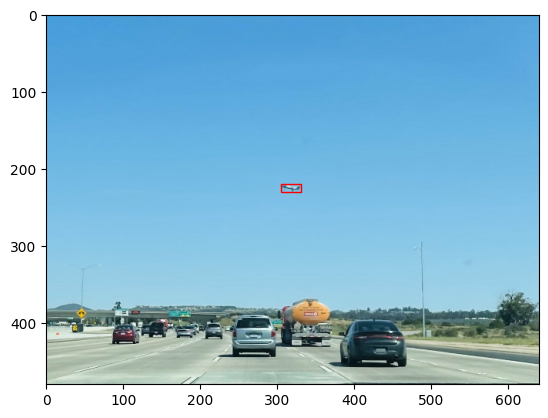

In [16]:

imgs, cords = next(gen)
print(imgs.shape)
plt.imshow(imgs)

# Get the current reference
ax = plt.gca()

# Create a Rectangle patch
x, y, w, h = list(map(float,cords))

w = int(w*640)
h = int(h*480)
x = int(x*640-w/2)
y = int(y*480-h/2)
rect = Rectangle((x,y),w,h,linewidth=1,edgecolor='r',facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()

In [45]:
test_path = Path('img/0c749a154cc436292bce152ee75ba158.jpg')

img = load_img(test_path)
import matplotlib.pyplot as plt
# plt.imshow(img)


pil_img = tf.keras.preprocessing.image.array_to_img(img)
# pil_img.show()
# plt.imshow(pil_img)

img\0c749a154cc436292bce152ee75ba158.jpg


# Create model

In [26]:
model = Sequential()

model.add(Input((480,640,3)))
model.add(Conv2D(32, 3, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128, 3, activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(4))


In [27]:
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.CategoricalFocalCrossentropy(from_logits=True),
  metrics=['accuracy'])


In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 478, 638, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 239, 319, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 237, 317, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 118, 158, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 116, 156, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 58, 78, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 56, 76, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 544768)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      69,730,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,861,124 (266.50 MB)

 Trainable params: 69,861,124 (266.50 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.fit(
  dataset,
  steps_per_epoch=40, 
  epochs=15   
)

Epoch 1/15


C:\Users\mpoly\miniconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


40/40 ━━━━━━━━━━━━━━━━━━━━ 216s 4s/step - accuracy: 0.3300 - loss: 0.6874
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.4150 - loss: 0.3349
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.4750 - loss: 0.3311
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.5250 - loss: 0.3262
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.6230 - loss: 0.3206
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.6670 - loss: 0.3167
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.7350 - loss: 0.3129
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.7430 - loss: 0.3107
Epoch 9/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.7720 - loss: 0.3091
Epoch 10/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.8090 - loss: 0.3080
Epoch 11/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.8340 - loss: 0.3072
Epoch 12/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.8220 - l

<Axes: >

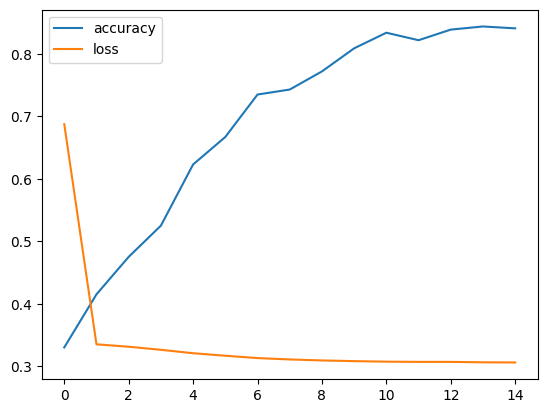

In [30]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [31]:
model.save('model_v1_0922_1510.h5')

In [4]:
#create the common input layer
input_shape = (480, 640, 3)
input_layer = tf.keras.layers.Input(input_shape)

#create the base layers
base_layers = Rescaling(1./255, name='bl_1')(input_layer)
base_layers = layers.Conv2D(16, 3, padding='same', activation='relu', name='bl_2')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_3')(base_layers)
base_layers = layers.Conv2D(32, 3, padding='same', activation='relu', name='bl_4')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_5')(base_layers)
base_layers = layers.Conv2D(64, 3, padding='same', activation='relu', name='bl_6')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_7')(base_layers)
base_layers = layers.Conv2D(128, 3, padding='same', activation='relu', name='bl_8')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_9')(base_layers)
base_layers = layers.Flatten(name='bl_10')(base_layers)

In [ ]:
#create the classifier branch
# classifier_branch = layers.Dense(128, activation='relu', name='cl_1')(base_layers)
# classifier_branch = layers.Dense(num_classes, name='cl_head')(classifier_branch)  

In [5]:
#create the localiser branch
locator_branch = layers.Dense(128, activation='relu', name='bb_1')(base_layers)
locator_branch = layers.Dense(64, activation='relu', name='bb_2')(locator_branch)
locator_branch = layers.Dense(32, activation='relu', name='bb_3')(locator_branch)
locator_branch = layers.Dense(4, activation='sigmoid', name='bb_head')(locator_branch)

In [6]:
model = tf.keras.Model(input_layer,
           outputs=[locator_branch])

In [7]:
model.compile(loss=tf.keras.losses.CategoricalFocalCrossentropy(from_logits=True), optimizer='Adam', metrics=['accuracy'])

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 480, 640, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_1 (Rescaling)                     │ (None, 480, 640, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_2 (Conv2D)                        │ (None, 480, 640, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_3 (MaxPooling2D)                  │ (None, 240, 320, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_4 (Conv2D)                        │ (None, 240, 320, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_5 (MaxPooling2D)                  │ (None, 120, 160, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_6 (Conv2D)                        │ (None, 120, 160, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_7 (MaxPooling2D)                  │ (None, 60, 80, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_8 (Conv2D)                        │ (None, 60, 80, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_9 (MaxPooling2D)                  │ (None, 30, 40, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bl_10 (Flatten)                      │ (None, 153600)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bb_1 (Dense)                         │ (None, 128)                 │      19,660,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bb_2 (Dense)                         │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bb_3 (Dense)                         │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bb_head (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,768,836 (75.41 MB)

 Trainable params: 19,768,836 (75.41 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(
  dataset,
  steps_per_epoch=54, 
  epochs=15   
)

Epoch 1/15


C:\Users\mpoly\miniconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


54/54 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6000 - loss: 0.1582
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6141 - loss: 0.1525
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.6141 - loss: 0.1525
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6141 - loss: 0.1525
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6141 - loss: 0.1525
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 985ms/step - accuracy: 0.6141 - loss: 0.1525
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 988ms/step - accuracy: 0.6141 - loss: 0.1525
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 988ms/step - accuracy: 0.6141 - loss: 0.1525
Epoch 9/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 985ms/step - accuracy: 0.6141 - loss: 0.1525
Epoch 10/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6141 - loss: 0.1525
Epoch 11/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6141 - loss: 0.1525
Epoch 12/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6141 - 

<Axes: >

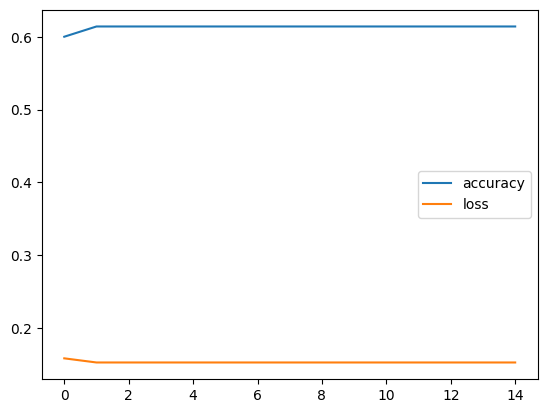

In [13]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [16]:
model.save('model_v2_0922_1330.h5')

In [56]:
model = load_model('model_v1_0922_1510.h5')

# Create test dataset

In [8]:
labels_path = Path('../lite_dataset/test/labels/')
img_path = Path('../lite_dataset/test/images/')


def load_img(path):
      if isinstance(path, Path): 
          path = str(path)
          
      img = tf.io.read_file(path)
      img = tf.io.decode_jpeg(img, channels=3)
      img = tf.cast(img, tf.float32)/255
      img = tf.image.resize(img, [480, 640])
      # img = tf.expand_dims(img, axis=0)
   
      return img

#create tf record of dataset
# writer = tf.io.TFRecordWriter('aircraft_dataset.tfrecord')    
@staticmethod
def data_generator():
    
    for file in labels_path.glob('*.txt'):
          coords = []
         
          filename = file.stem          
          img_path = Path(f'../lite_dataset/test/images/{filename}.jpg') 
          img = load_img(img_path)
         
          with open(file, 'r') as f:
              lines = f.readlines()
              for line in lines:
                  line = line.strip('\n')
                  obj_coord = line.split(' ')[1:]
                  coords = obj_coord 
                  break
          yield img, coords
         

test_ds = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=(
         tf.TensorSpec(shape=(480, 640, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(4), dtype=tf.float32))
)

test_ds = test_ds.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE).shuffle(200).batch(25) #.repeat()

In [22]:
model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step - accuracy: 0.3100 - loss: 0.4430


[0.4429900348186493, 0.3100000023841858]

In [23]:
model.evaluate(dataset)

40/40 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.3370 - loss: 0.4472


[0.44721707701683044, 0.3370000123977661]

In [25]:
prediction = model.predict(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 764ms/step


In [36]:
prediction[0]

array([ 0.6306809 ,  0.8697119 , -0.6455805 , -0.75353134], dtype=float32)

In [39]:
batch = test_ds.take(1)
print(batch)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 480, 640, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[-0.3342338  -0.19731632  0.19905666  0.0353788 ]


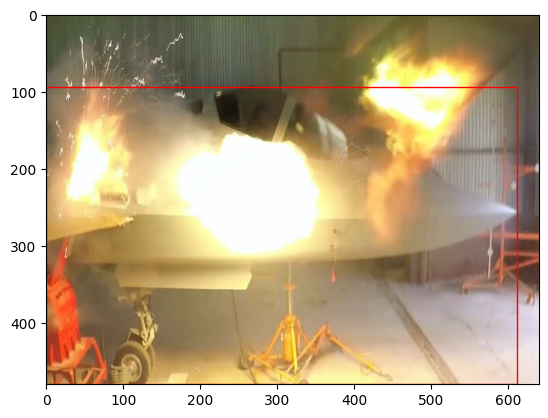

[ 0.05560023  0.17130396 -0.5612687  -0.8135297 ]


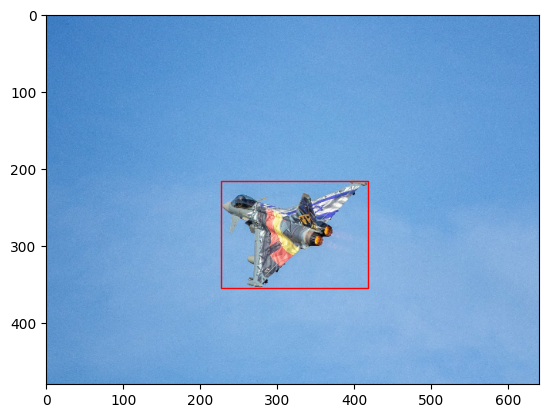

[-0.15298338 -0.3260423   0.30303168  0.12894659]


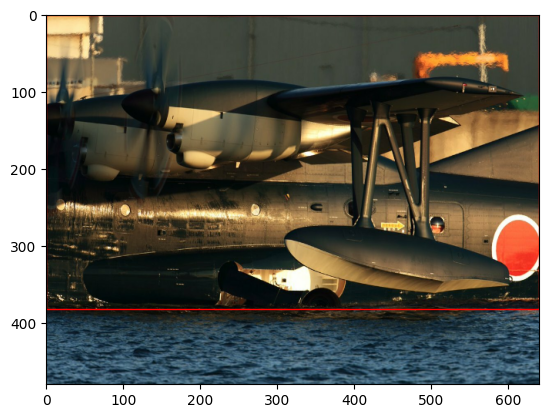

[-0.12001335 -0.57659245  0.28383029 -0.19433141]


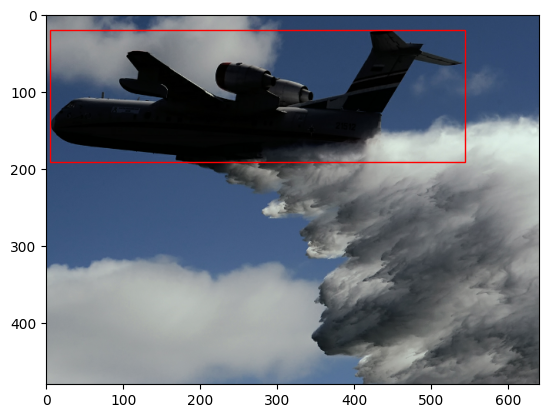

[ 0.2877841  0.1606128 -0.9654725 -0.9357492]


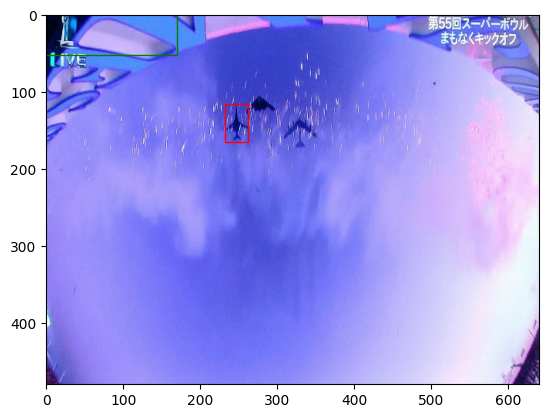

[ 0.7832791   0.16225186 -1.1043985  -0.6359085 ]


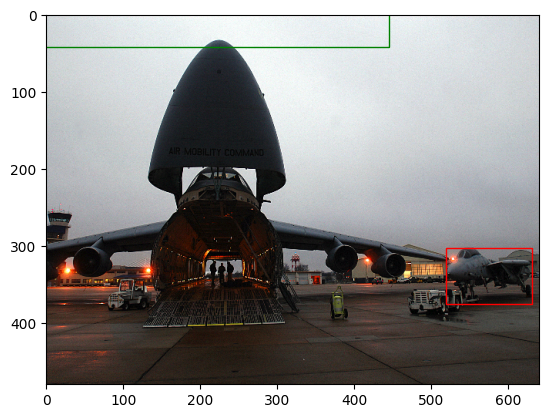

[-0.06540892 -0.2745872   0.06997371 -0.34381   ]


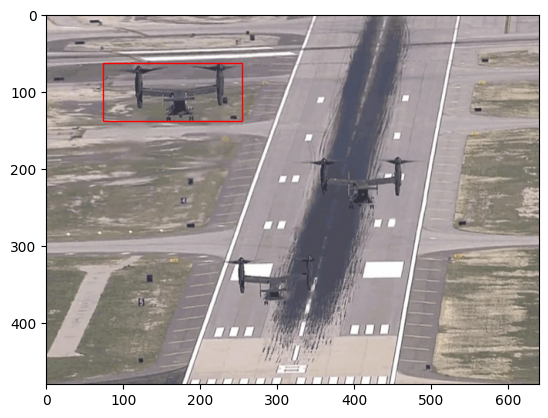

[-0.08861267 -0.2988944   0.21953231 -0.2716004 ]


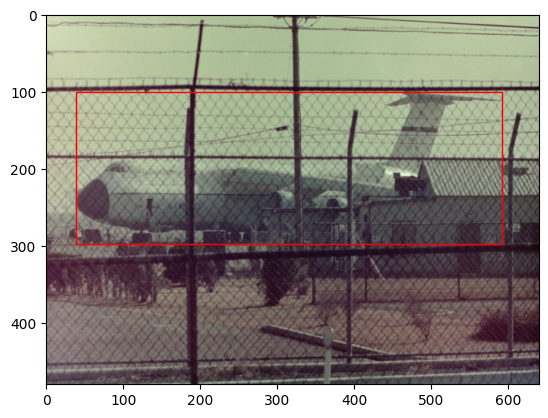

[-0.2147053  -0.28447965  0.09566008  0.12231666]


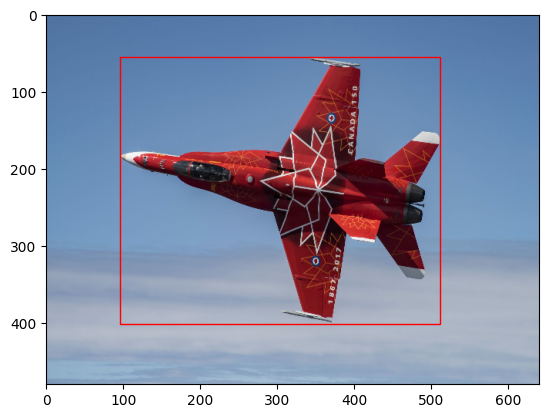

[-0.05806493 -0.08719728 -0.48364398 -0.7223479 ]


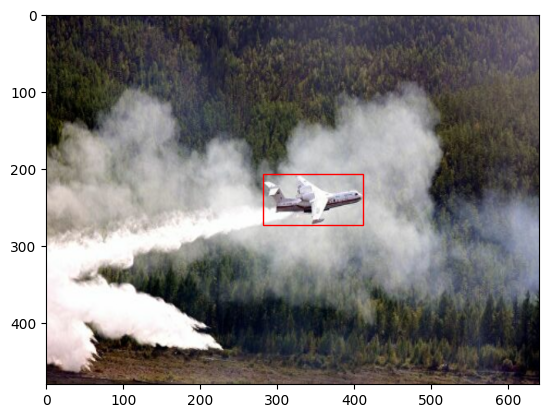

[ 0.01384366  0.25561467 -0.23212935 -0.7631851 ]


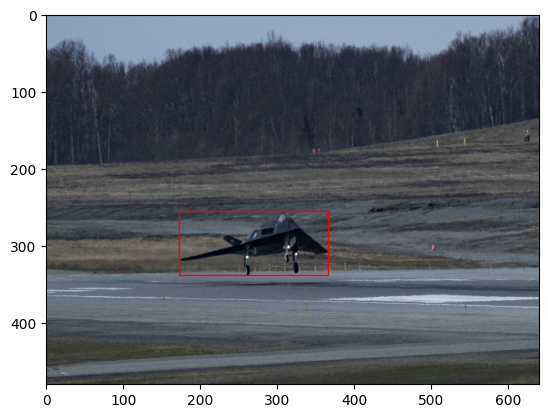

[-0.12348058 -0.20630367  0.24375467  0.08929247]


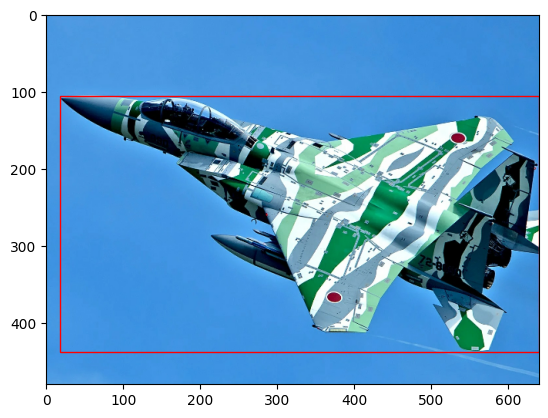

[-0.0337391  -0.3190684   0.00188873 -0.36042067]


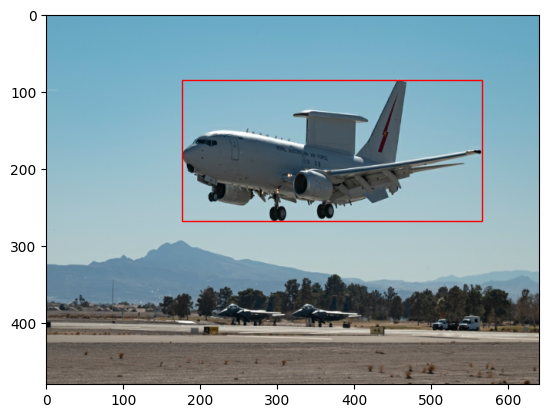

[-0.07539122 -0.2411784   0.325925    0.03430872]


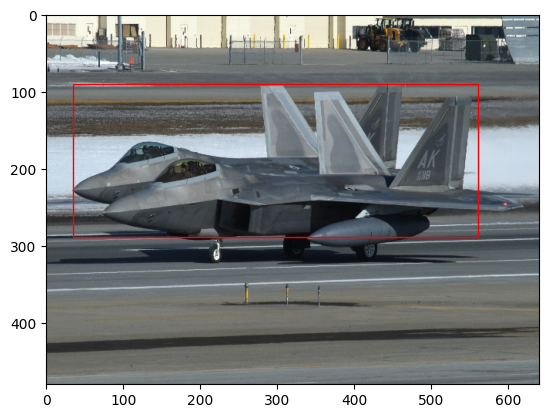

[ 0.6259201   0.02083314 -1.2150339  -1.4780135 ]


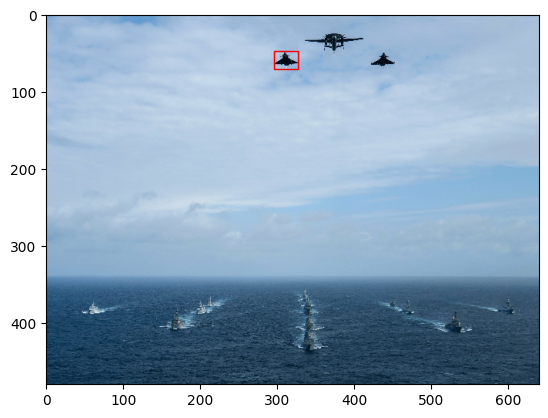

[ 0.39330414  0.01047972 -0.61599785 -0.40880257]


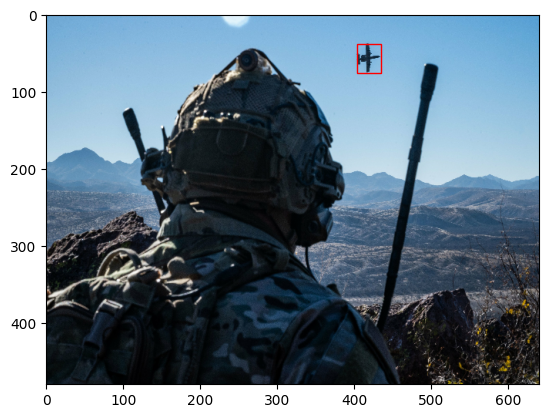

[-0.04035778  0.10486427 -0.1483243  -0.89614606]


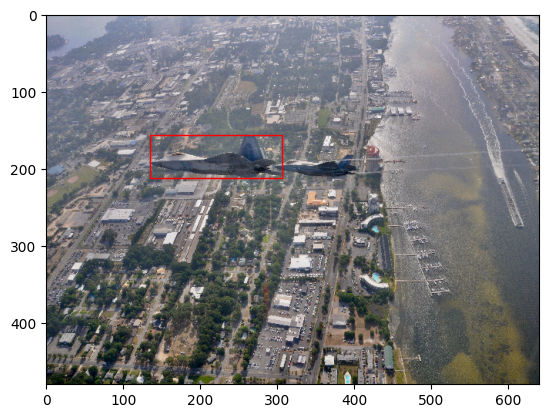

[ 0.2345092   0.24327263 -0.9071953  -1.0201873 ]


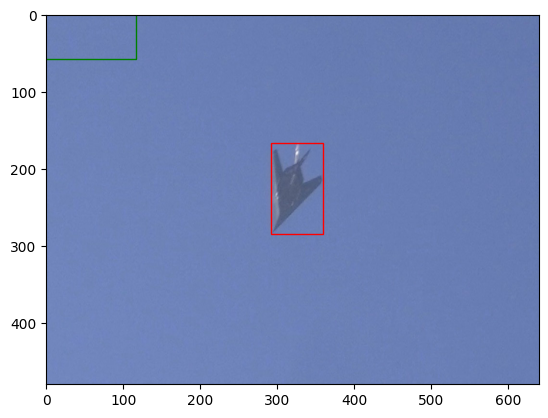

[-0.03306299  0.62072533 -0.03656567 -0.45847636]


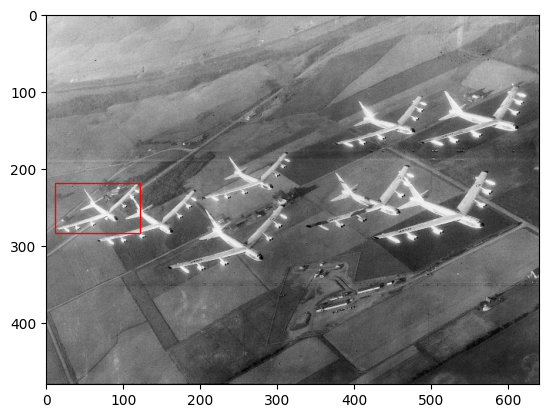

[ 0.5089673   0.20676953 -0.40962958 -1.0322675 ]


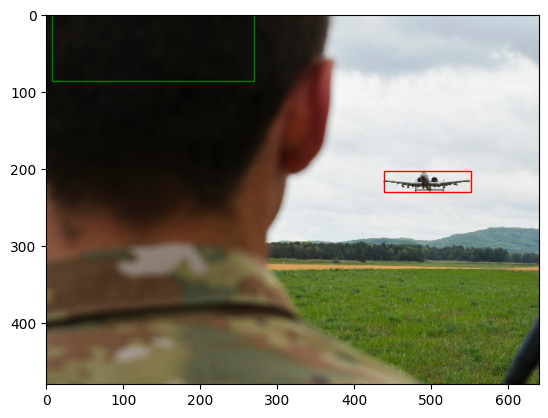

[-0.31415367 -0.33037615  0.07522225  0.17971593]


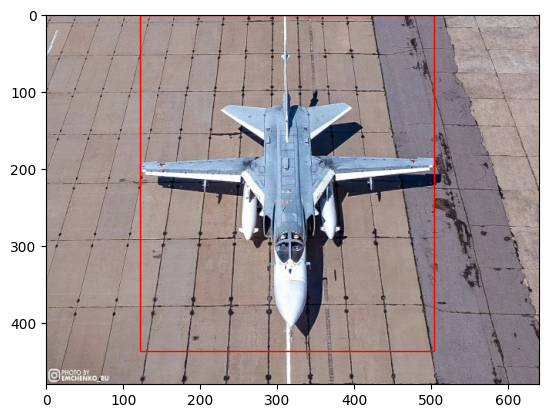

[-0.092267   -0.24935132 -0.23308085  0.12869674]


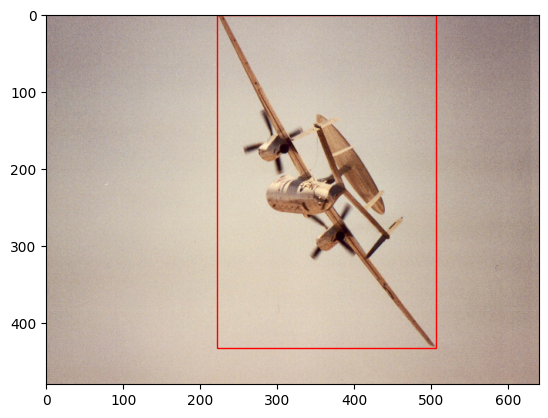

[-0.20900403 -0.2998579   0.27403715  0.03709639]


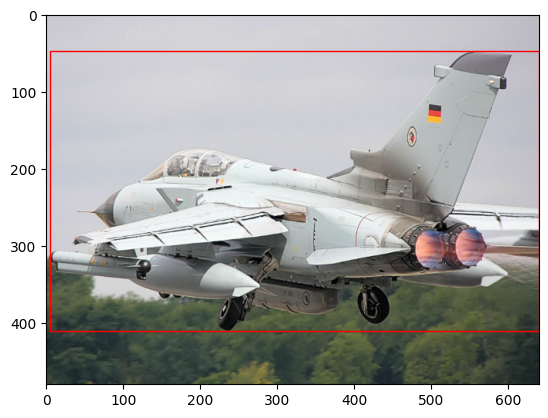

[ 0.2134142   0.15990649 -0.60448974 -1.2123579 ]


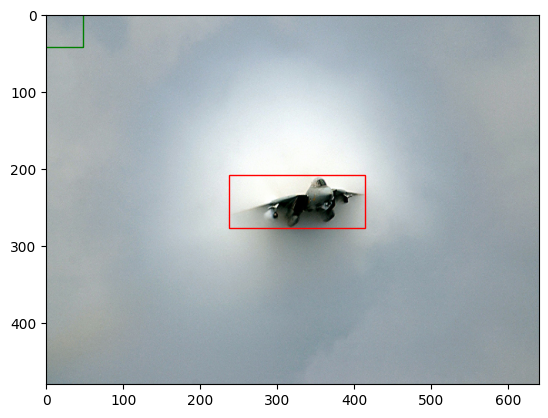

[ 0.13051167  0.20648804 -0.789265   -1.2808841 ]


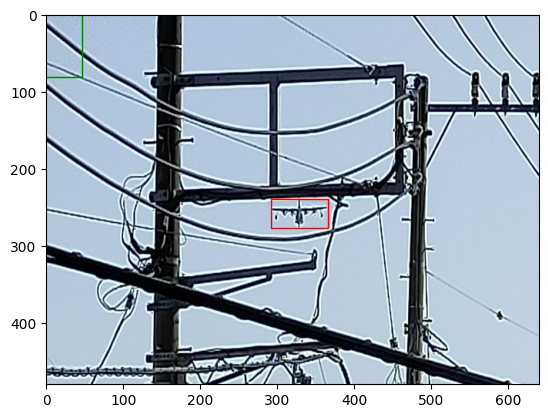

In [63]:

iter = 0

for imgs, coords in test_ds:
    prediction = model.predict(imgs)
    for element in zip(imgs,coords,prediction):
        # print(element[0])
        plt.imshow(element[0])
        
                # Get the current reference
        ax = plt.gca()
        
        # Create a Rectangle patch
        x, y, w, h = list(map(float,element[1]))
        
        w = int(w*640)
        h = int(h*480)
        x = int(x*640-w/2)
        y = int(y*480-h/2)
        rect = Rectangle((x,y),w,h,linewidth=1,edgecolor='r',facecolor='none')
        
        # Add the patch to the Axes
        ax.add_patch(rect)
        
        #add prediction
        print(element[2])
        x1, y1, w1, h1 = list(map(float,element[2]))
        
        w1 = int(w1*640)
        h1 = int(h1*480)
        x1 = int(x1*640-w/2)
        y1 = int(y1*480-h/2)
        rect1 = Rectangle((x1,y1),w1,h1,linewidth=1,edgecolor='g',facecolor='none')
        
        # Add the patch to the Axes
        ax.add_patch(rect1)
        
        
        plt.show()
    iter += 1
    if iter >= 1:
        break



In [64]:
def load_img(path):
      if isinstance(path, Path): 
          path = str(path)
          
      img = tf.io.read_file(path)
      img = tf.io.decode_jpeg(img, channels=3)
      img = tf.cast(img, tf.float32)/255
      img = tf.image.resize(img, [480, 640])
      img = tf.expand_dims(img, axis=0)
   
      return img


In [68]:
img_path = Path('img/0c749a154cc436292bce152ee75ba158.jpg')
img = load_img(img_path)
coord = model.predict(img)
print(coord[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
[-0.22557363 -0.15209466 -0.12064281  0.21498248]


In [5]:
from  evaluation import  evaluate_model
from datasets import load_dataset

In [6]:
model = load_model('model_v1_0922_1510.h5')


def cast_img(img):

    img = tf.convert_to_tensor(img, dtype=tf.int32)
    img = tf.cast(img, tf.float32) / 255
    img = tf.image.resize(img, [480, 640])
    img = tf.expand_dims(img, axis=0)
    
    return img

def tf_model_prediction(img):
    img = cast_img(img)
    coord = model.predict(img)
    x_center, y_center, width, height = coord[0]
    
    return {'x_center': x_center, 'y_center': y_center, 'width': width, 'height': height}

In [7]:
path = '../lite_dataset'
dataset_hf = load_dataset("imagefolder",data_dir=path, streaming=True)

Resolving data files:   0%|          | 0/2002 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/402 [00:00<?, ?it/s]

In [8]:
evaluate_model(tf_model_prediction,dataset_hf)

0it [00:00, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━